[INFO] Successfully loaded 3764 total valid data points.


,Ground Truth (m),Node,Samples,Mean Dist (m),Median Dist (m),Std Dev (cm),Mean Error (cm),Drift Rate (mm/s),Drift R^2,Mean RSSI (dBm)
0,1.0,Robot 1,262,0.588,0.63,18.00,-41.2,4.511,0.902,-63.8
1,1.0,Robot 2,256,0.592,0.63,17.09,-40.8,4.404,0.910,-63.6
2,2.0,Robot 1,419,1.887,1.93,13.56,-11.3,2.099,0.878,-65.3
3,2.0,Robot 2,428,1.883,1.93,14.04,-11.7,2.130,0.880,-65.3
4,3.0,Robot 1,349,2.905,2.95,18.30,-9.5,3.484,0.923,-72.0
5,3.0,Robot 2,353,2.903,2.96,18.74,-9.7,3.520,0.918,-72.0
6,4.0,Robot 1,392,4.280,4.34,20.58,28.0,3.468,0.911,-78.1
7,4.0,Robot 2,395,4.279,4.34,20.81,27.9,3.473,0.908,-78.0
8,5.0,Robot 1,458,5.497,5.46,15.43,49.7,2.188,0.881,-81.7
9,5.0,Robot 2,452,5.501,5.46,14.97,50.1,2.163,0.891,-81.7


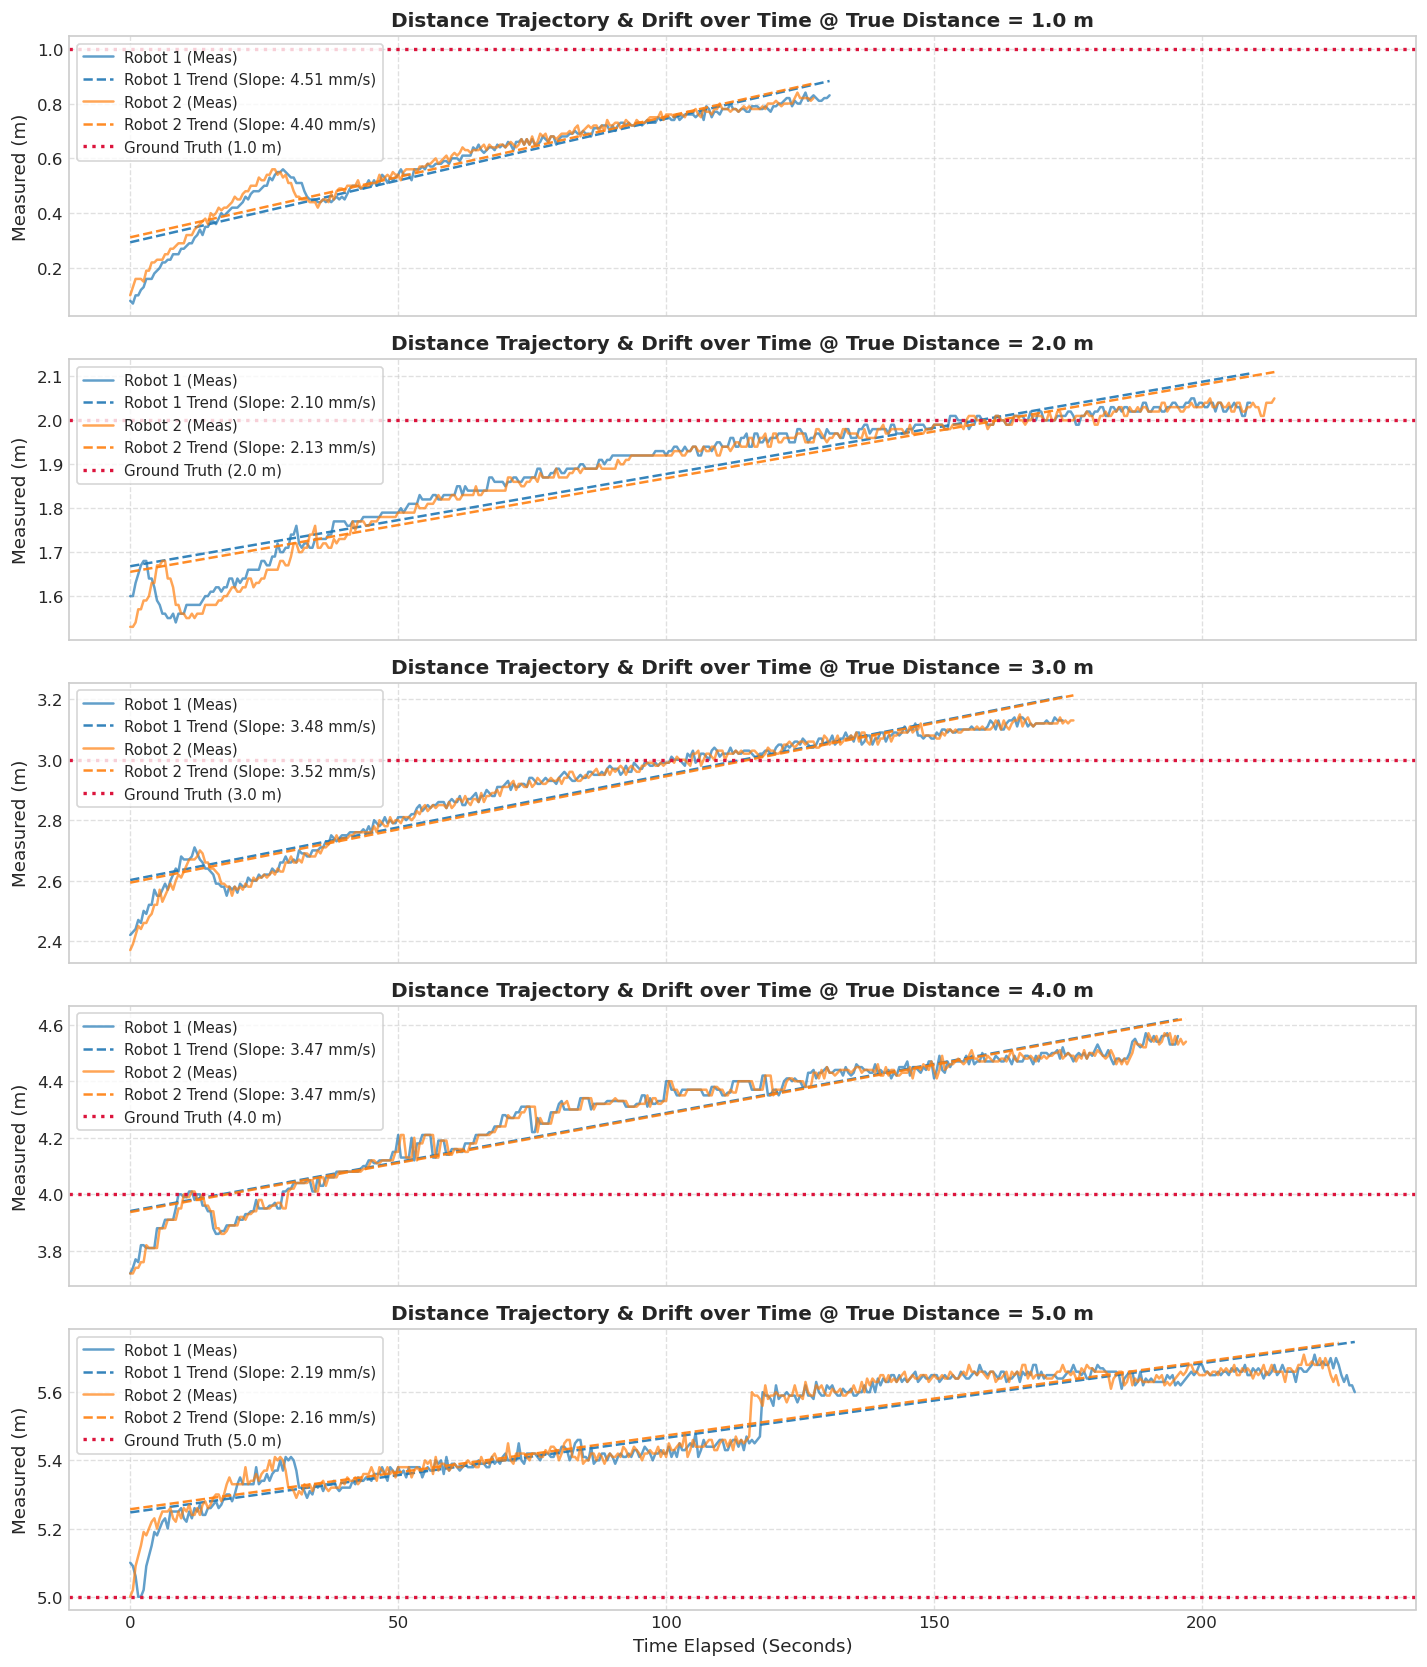

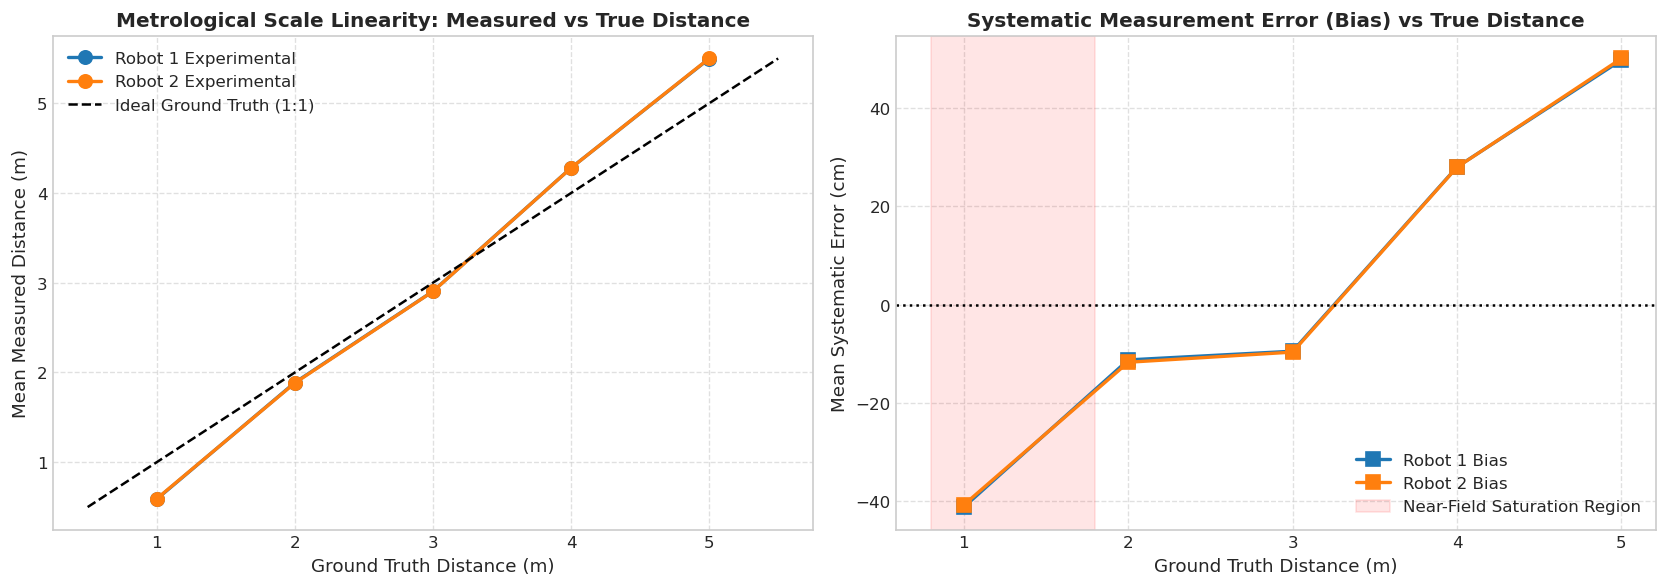

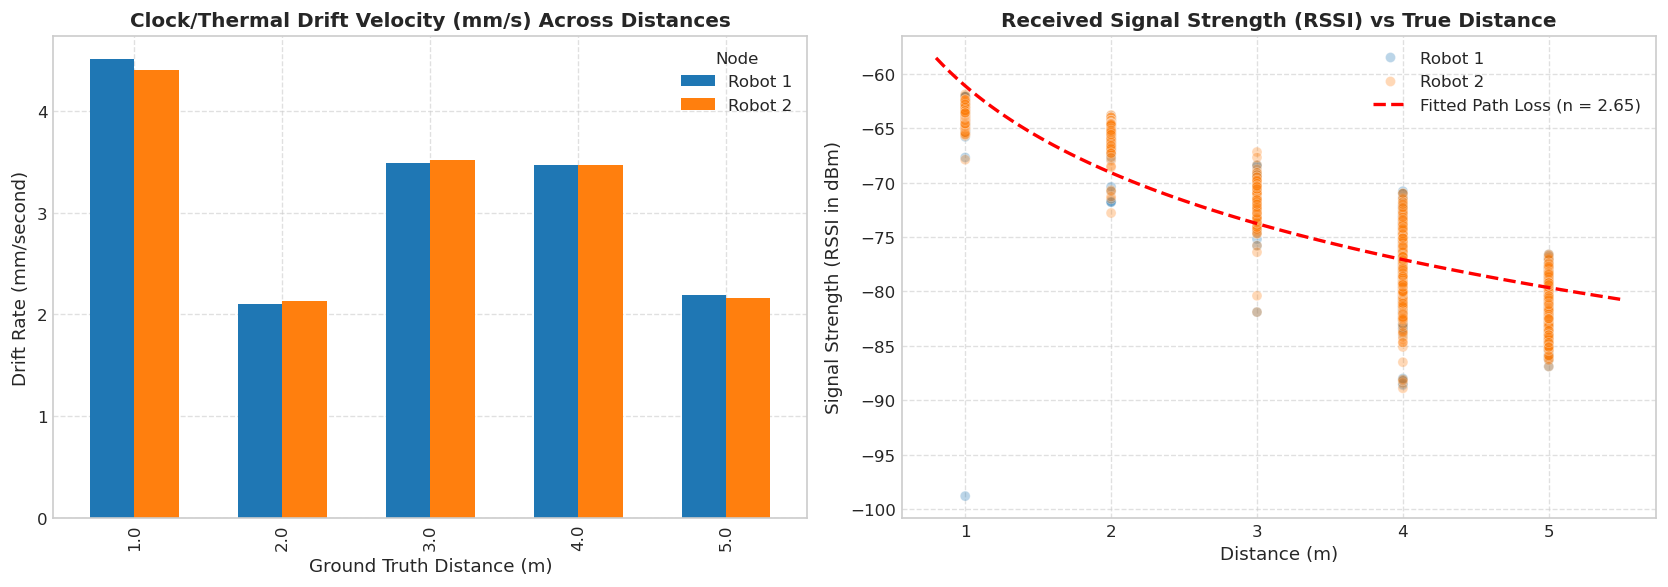

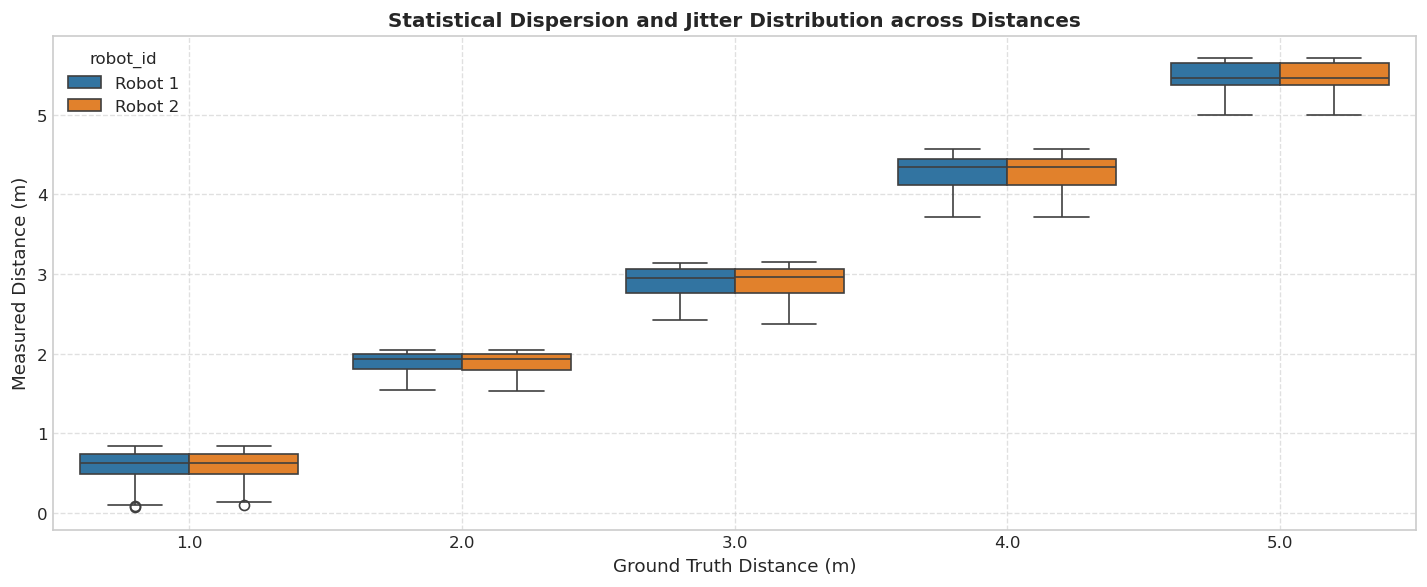

In [1]:
# %% [markdown]
# # Anjoman Swarm: Multi-Distance UWB Metrology & Drift Analysis
# **Datasets:** `r1_1m.txt` to `r1_5m.txt` and `r2_1m.txt` to `r2_5m.txt`
# **Metrics:** Power-induced bias, Temporal drift slope ($\beta$), Path Loss, and Scale linearity ($m_c$).

# %%
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure aesthetic styling for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

# %% [markdown]
# ### 1. Dataset Parser & Feature Extractor

# %%
def parse_dataset_files(distances=[1, 2, 3, 4, 5], prefix_r1="r1", prefix_r2="r2"):
    """
    Parses raw log files for Robots 1 and 2 across all test distances.
    Extracts calibrated distance, raw distance, RSSI, sequence IDs, and time elapsed.
    """
    data_records = []
    regex_pattern = re.compile(
        r'Distance:\s*([\d\.\-]+)\s*m.*?RSSI:\s*([\d\.\-]+)\s*dBm.*?Ex:\s*(\d+)',
        re.IGNORECASE
    )

    for d_true in distances:
        for robot_id, prefix in [(1, prefix_r1), (2, prefix_r2)]:
            filename = f"{prefix}_{d_true}m.txt"
            if not os.path.exists(filename):
                print(f"[WARN] File not found: {filename} (Skipping)")
                continue

            with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
                sample_idx = 0
                for line in f:
                    match = regex_pattern.search(line)
                    if match:
                        dist_val = float(match.group(1))
                        rssi_val = float(match.group(2))
                        ex_val = int(match.group(3))

                        # Outlier rejection filter for corrupt packets
                        if -5.0 < dist_val < 30.0:
                            data_records.append({
                                'robot_id': f"Robot {robot_id}",
                                'ground_truth_m': float(d_true),
                                'sample_idx': sample_idx,
                                'time_sec': sample_idx * 0.5, # 2 Hz sampling period
                                'measured_dist_m': dist_val,
                                'error_m': dist_val - float(d_true),
                                'rssi_dbm': rssi_val,
                                'exchange_id': ex_val
                            })
                            sample_idx += 1

    df = pd.DataFrame(data_records)
    print(f"[INFO] Successfully loaded {len(df)} total valid data points.")
    return df

df = parse_dataset_files()
df.head()

# %% [markdown]
# ### 2. Statistical Metrology & Linear Regression Table

# %%
summary_list = []

for (gt, rid), group in df.groupby(['ground_truth_m', 'robot_id']):
    n_samples = len(group)
    mean_val = group['measured_dist_m'].mean()
    median_val = group['measured_dist_m'].median()
    std_val = group['measured_dist_m'].std()
    min_val = group['measured_dist_m'].min()
    max_val = group['measured_dist_m'].max()
    mean_err = group['error_m'].mean()
    mean_rssi = group['rssi_dbm'].mean()

    # Linear OLS Drift Regression: d(t) = d_0 + beta * t
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['time_sec'], group['measured_dist_m'])
    drift_mm_per_sec = slope * 1000.0 # mm/s

    summary_list.append({
        'Ground Truth (m)': gt,
        'Node': rid,
        'Samples': n_samples,
        'Mean Dist (m)': np.round(mean_val, 3),
        'Median Dist (m)': np.round(median_val, 3),
        'Std Dev (cm)': np.round(std_val * 100.0, 2),
        'Mean Error (cm)': np.round(mean_err * 100.0, 1),
        'Drift Rate (mm/s)': np.round(drift_mm_per_sec, 3),
        'Drift R^2': np.round(r_value**2, 3),
        'Mean RSSI (dBm)': np.round(mean_rssi, 1)
    })

df_summary = pd.DataFrame(summary_list).sort_values(by=['Ground Truth (m)', 'Node'])
display(df_summary)

# %% [markdown]
# ### 3. Figure 1: Temporal Distance Trajectories & Dynamic Drift Curves

# %%
fig, axes = plt.subplots(len(df['ground_truth_m'].unique()), 1, figsize=(12, 14), sharex=True)
colors = {'Robot 1': '#1f77b4', 'Robot 2': '#ff7f0e'}

for idx, (gt, ax) in enumerate(zip(sorted(df['ground_truth_m'].unique()), axes)):
    sub_df = df[df['ground_truth_m'] == gt]
    
    for rid in ['Robot 1', 'Robot 2']:
        node_data = sub_df[sub_df['robot_id'] == rid]
        if not node_data.empty:
            ax.plot(node_data['time_sec'], node_data['measured_dist_m'], 
                    label=f"{rid} (Meas)", color=colors[rid], alpha=0.7, lw=1.5)
            
            # Trendline
            z = np.polyfit(node_data['time_sec'], node_data['measured_dist_m'], 1)
            p = np.poly1d(z)
            ax.plot(node_data['time_sec'], p(node_data['time_sec']), 
                    linestyle='--', color=colors[rid], alpha=0.9, 
                    label=f"{rid} Trend (Slope: {z[0]*1000:.2f} mm/s)")

    ax.axhline(y=gt, color='crimson', linestyle=':', lw=2, label=f"Ground Truth ({gt:.1f} m)")
    ax.set_title(f"Distance Trajectory & Drift over Time @ True Distance = {gt:.1f} m", fontweight='bold')
    ax.set_ylabel("Measured (m)")
    ax.legend(loc='upper left', frameon=True, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel("Time Elapsed (Seconds)")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4. Figure 2: Metrological Scale Linearity ($m_c$) & Near-Field Saturation Bias

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: True vs Measured Distance (Scale Linearity)
mean_pts = df.groupby(['ground_truth_m', 'robot_id'])['measured_dist_m'].mean().reset_index()

for rid in ['Robot 1', 'Robot 2']:
    sub_pts = mean_pts[mean_pts['robot_id'] == rid]
    ax1.plot(sub_pts['ground_truth_m'], sub_pts['measured_dist_m'], 
             marker='o', markersize=8, lw=2, label=f"{rid} Experimental")

# Reference Ideal 1:1 Line
ideal_x = np.linspace(0.5, 5.5, 100)
ax1.plot(ideal_x, ideal_x, 'k--', lw=1.5, label='Ideal Ground Truth (1:1)')
ax1.set_title("Metrological Scale Linearity: Measured vs True Distance", fontweight='bold')
ax1.set_xlabel("Ground Truth Distance (m)")
ax1.set_ylabel("Mean Measured Distance (m)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: Error vs Ground Truth (Visualizing Near-Field Receiver Saturation)
err_pts = df.groupby(['ground_truth_m', 'robot_id'])['error_m'].mean().reset_index()

for rid in ['Robot 1', 'Robot 2']:
    sub_err = err_pts[err_pts['robot_id'] == rid]
    ax2.plot(sub_err['ground_truth_m'], sub_err['error_m'] * 100.0, 
             marker='s', markersize=8, lw=2, label=f"{rid} Bias")

ax2.axhline(0, color='black', linestyle=':', lw=1.5)
ax2.axvspan(0.8, 1.8, color='red', alpha=0.1, label='Near-Field Saturation Region')
ax2.set_title("Systematic Measurement Error (Bias) vs True Distance", fontweight='bold')
ax2.set_xlabel("Ground Truth Distance (m)")
ax2.set_ylabel("Mean Systematic Error (cm)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 5. Figure 3: Drift Rate ($\beta$) Dynamics & RSSI Path Loss Attenuation

# %%
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Drift Rate vs Distance
df_drift = df_summary.pivot(index='Ground Truth (m)', columns='Node', values='Drift Rate (mm/s)')
df_drift.plot(kind='bar', ax=ax1, color=['#1f77b4', '#ff7f0e'], width=0.6)
ax1.set_title("Clock/Thermal Drift Velocity (mm/s) Across Distances", fontweight='bold')
ax1.set_ylabel("Drift Rate (mm/second)")
ax1.set_xlabel("Ground Truth Distance (m)")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot B: RSSI Path Loss Attenuation Model
rssi_summary = df.groupby('ground_truth_m')['rssi_dbm'].mean().reset_index()
d_vals = rssi_summary['ground_truth_m'].values
rssi_vals = rssi_summary['rssi_dbm'].values

# Fit Logarithmic Path Loss Model: RSSI = P0 - 10 * n * log10(d)
log_d = np.log10(d_vals)
fit_slope, fit_intercept, _, _, _ = stats.linregress(log_d, rssi_vals)
path_loss_exp = -fit_slope / 10.0

d_dense = np.linspace(0.8, 5.5, 100)
rssi_model = fit_intercept + fit_slope * np.log10(d_dense)

sns.scatterplot(data=df, x='ground_truth_m', y='rssi_dbm', hue='robot_id', alpha=0.3, ax=ax2)
ax2.plot(d_dense, rssi_model, 'r--', lw=2, label=f"Fitted Path Loss (n = {path_loss_exp:.2f})")
ax2.set_title("Received Signal Strength (RSSI) vs True Distance", fontweight='bold')
ax2.set_xlabel("Distance (m)")
ax2.set_ylabel("Signal Strength (RSSI in dBm)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 6. Figure 4: Noise Distributions & Jitter Boxplots

# %%
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='ground_truth_m', y='measured_dist_m', hue='robot_id', palette=['#1f77b4', '#ff7f0e'])
plt.title("Statistical Dispersion and Jitter Distribution across Distances", fontweight='bold')
plt.xlabel("Ground Truth Distance (m)")
plt.ylabel("Measured Distance (m)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()